### 1. Kutubxonalarni yuklash (import libraries)

In [77]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

### 2. Ma'lumotlarni to'plamini yuklash (Load dataset)

In [78]:
df = pd.read_csv(r"C:\Users\Maftuna\Downloads\heart (1).csv")

In [57]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### 3. Ma'lumotlarni ML modeli uchun tayyorlash 

In [59]:
df.target.unique()

array([1, 0], dtype=int64)

In [60]:
df['target'].unique()

array([1, 0], dtype=int64)

In [61]:
x = df.drop('target', axis= 1)
y= df['target']

In [62]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [63]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


### 4. Modelni o'qitish (Model Training)

In [67]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(x_train, y_train)

GaussianNB()

### 5. Bashorat qilish (Pridict )

In [69]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

### 6. Modelni aniqligini baholash (Evalution)

In [71]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Modelni aniqligini baholash 
accuracy = accuracy_score(y_test, y_pred)
print("Aniqligi:", accuracy)
print("\nKlassifikatsiya hisoboti:")
print(classification_report(y_test, y_pred))

# Confusion matricni chop etish 
print("Confution Matric:")
print(confusion_matrix(y_test, y_pred))

Aniqligi: 0.8688524590163934

Klassifikatsiya hisoboti:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Confution Matric:
[[26  3]
 [ 5 27]]


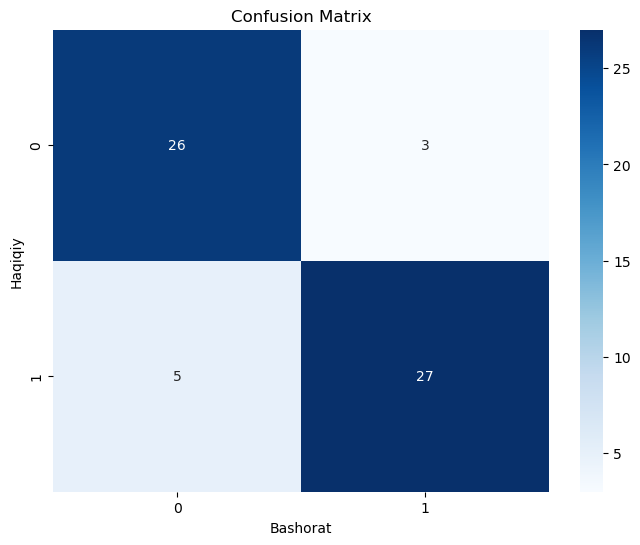

In [74]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt='d', cmap = 'Blues')
plt.xlabel("Bashorat")
plt.ylabel("Haqiqiy")
plt.title("Confusion Matrix")
plt.show()



### 7. Modelni saqlash

In [76]:
import joblib 

# o'qitilgan modelni saqlash 
joblib.dump(model, "Naive_Bayes_Heart_Prediction_model.pkl")

# Saqlab qo'yilgan modelni yuklab
loaded_model = joblib.load("Naive_Bayes_Heart_Prediction_model.pkl")

# Yuklab olingan modeldan foydalanish 
y_pred = loaded_model.predict(x_test)
print("Test Aniqligi:", accuracy_score(y_test, y_pred))

Test Aniqligi: 0.8688524590163934


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
